In [2]:
#Upload dataset
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [25]:
# Import Libraries
import pandas as pd
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

#Load dataset
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")
print(fake.head())
print(real.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [4]:
#Add Labels
fake["label"] = 0
real["label"] = 1

In [32]:
#Combine Dataset
data = pd.concat([fake, real])

print(data.shape)
print(data.head())

(44898, 4)
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [27]:
#Clean Text

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text
data["text"] = data["text"].apply(clean_text)

In [38]:

#create label column
data["label"] = data["subject"].apply(lambda x: 0 if x == "News" else 1)

In [50]:
#TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Create vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit and transform dataset text
X = vectorizer.fit_transform(data['text'])

# Labels
y = data['label']

In [41]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
#Train Model
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7, max_features=5000)

from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [43]:
#Check Accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9926503340757238


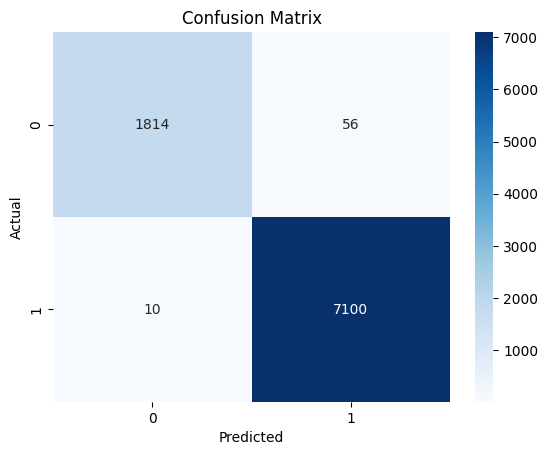

In [45]:
#Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Plot heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

#Add labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

#Show the graph
plt.show()

In [57]:
data["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [62]:
def label_subject(x):
    real_news = ['News', 'worldnews', 'Government News', 'US_News', 'Middle-east']
    if x in real_news:
        return 0 # Real
    else:
        return 1  # Fake

data['label'] = data['subject'].apply(label_subject)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X = vectorizer.fit_transform(data["text"])
y = data["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train, y_train)

PassiveAggressiveClassifier(max_iter=50)

In [64]:
#Test News Input Widget

# Install ipywidgets if not installed
!pip install ipywidgets --quiet

# Import widgets and display
import ipywidgets as widgets
from IPython.display import display
# Input box
news_input = widgets.Text(
    value='',
    placeholder='Type your news here...',
    description='News:',
    layout=widgets.Layout(width='80%')
)

# Output area
output = widgets.Output()

# Button to predict
button = widgets.Button(description="Check News", button_style='success')

def on_button_click(b):
    with output:
        output.clear_output()
        news_vector = vectorizer.transform([news_input.value])
        prediction = model.predict(news_vector)
        if prediction[0] == 0:
            print("❌ Fake News")
        else:
            print("✅ Real News")

button.on_click(on_button_click)

display(news_input, button, output)

Text(value='', description='News:', layout=Layout(width='80%'), placeholder='Type your news here...')

Button(button_style='success', description='Check News', style=ButtonStyle())

Output()

In [66]:
#Save the model
import pickle

pickle.dump(model, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))
import pickle

# Save the trained model
pickle.dump(model, open("fake_news_model.pkl", "wb"))
